In [1]:
import copy
import numpy as np
import pandas as pd
import uproot as ur
from numba import jit
from matplotlib import pyplot as plt
from matplotlib.ticker import NullFormatter, AutoMinorLocator, MultipleLocator, FuncFormatter

# XGBoost 
import xgboost as xgb
from xgboost import XGBClassifier # this is an API from Scikit-Learn
from xgboost import plot_importance # and this is a Plot API
#, to_graphviz, plot_tree hope we don't need those

# for the optimization of the parameters
# to perform Kfold
from sklearn.model_selection import KFold 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, RocCurveDisplay, roc_curve, roc_auc_score, auc
# used in the ROC curve analysis
from sklearn.preprocessing import LabelBinarizer # maybe this can be an alternative to multiclass

from hyperopt import tpe, hp, fmin, Trials, STATUS_OK
# from hpsklearn import HyperoptEstimator, xgboost_classification

import shap


print("XGBoost version:", xgb.__version__)

XGBoost version: 3.0.4


In [2]:
# setting random seed for reproducibility
np.random.seed(2150237)
# I don't know if the numpy interface is more efficient or only more resources consuming
numpy_interface = True
# preliminary Y cut, to be seen
fY_cut = 0.8
# deciding how many dataframe to use for the background data sampling
double_df = False
# double_df = True

In [3]:
# these are the lists we use for selecting columns and train
# base xgboost training
train_columns_D0 = [ 
                     'fChi2PCA', 
                     'fDecayLength', 
                     'fDecayLengthXY', 
                     'fImpactParameter0', 
                     'fImpactParameter1',
                     'fImpactParameterProduct',
                     'fCpa',
                     'fCpaXY'
                   ]
# extended xgboost training
train_columns_D0_extra = [ 
                     'fChi2PCA', 
                     'fDecayLength', 
                     'fDecayLengthXY', 
                     'fImpactParameter0', 
                     'fImpactParameter1',
                     'fImpactParameterProduct',
                     'fCpa',
                     'fCpaXY',
                     'fNSigTpcPi0' ,
                     'fNSigTpcKa0' ,
                     'fNSigTofPi0' ,
                     'fNSigTofKa0' ,
                     'fNSigTpcTofPi0' ,
                     'fNSigTpcTofKa0' ,
                     'fNSigTpcPi1' ,
                     'fNSigTpcKa1' ,
                     'fNSigTofPi1' ,
                     'fNSigTofKa1' ,
                     'fNSigTpcTofPi1' ,
                     'fNSigTpcTofKa1' 
                   ]
# base xgboost training
train_columns_LC = [ 
                     'fChi2PCA', 
                     'fDecayLength', 
                     'fDecayLengthXY', 
                     'fImpactParameter0', 
                     'fImpactParameter1',
                     'fImpactParameter2',
                     'fCpa',
                     'fCpaXY',
                     'fCt'
                   ]
# extended xgboost training
train_columns_LC_extra = [ 
                     'fChi2PCA', 
                     'fDecayLength', 
                     'fDecayLengthXY', 
                     'fImpactParameter0', 
                     'fImpactParameter1',
                     'fImpactParameter2',
                     'fCpa',
                     'fCpaXY',
                     'fCt',
                     'fNSigTpcPi0' ,
                     'fNSigTpcPr0' ,
                     'fNSigTofPi0' ,
                     'fNSigTofPr0' ,
                     'fNSigTpcKa1' ,
                     'fNSigTofKa1' ,
                     'fNSigTpcPi2' ,
                     'fNSigTpcPr2' ,
                     'fNSigTofPi2' ,
                     'fNSigTofPr2' ,
                     'fNSigTpcTofPi0' ,
                     'fNSigTpcTofPr0' ,
                     'fNSigTpcTofKa1' ,
                     'fNSigTpcTofPi2' ,
                     'fNSigTpcTofPr2' 
                   ]
# minimum for xgboost
DZ_columns_base = [
                    'fChi2PCA',
                    'fDecayLength',
                    'fDecayLengthXY',
                    'fImpactParameter0',
                    'fImpactParameter1',
                    'fCpa',
                    'fCpaXY',
                    'fM',
                    'fPt',
                    'fY',
                    'fOriginMcRec',
                    'fImpactParameterProduct',
                    'fCandidateSelFlag',
                    'fFlagMc'
]
# extended xgboost option, maybe for preselection
DZ_columns_ex = [
                    'fChi2PCA',
                    'fDecayLength',
                    'fDecayLengthXY',
                    'fImpactParameter0',
                    'fImpactParameter1',
                    'fCpa',
                    'fCpaXY',
                    'fM',
                    'fPt',
                    'fY',
                    'fOriginMcRec',
                    'fImpactParameterProduct',
                    'fCandidateSelFlag',
                    'fFlagMc',
                    'fNSigTpcPi0' ,
                    'fNSigTpcKa0' ,
                    'fNSigTofPi0' ,
                    'fNSigTofKa0' ,
                    'fNSigTpcTofPi0' ,
                    'fNSigTpcTofKa0' ,
                    'fNSigTpcPi1' ,
                    'fNSigTpcKa1' ,
                    'fNSigTofPi1' ,
                    'fNSigTofKa1' ,
                    'fNSigTpcTofPi1' ,
                    'fNSigTpcTofKa1' 
]

# minimum for xgboost
LC_columns_base = [
                    'fChi2PCA',
                    'fDecayLength',
                    'fDecayLengthXY',
                    'fImpactParameter0',
                    'fImpactParameter1',
                    'fImpactParameter2' ,
                    'fCpa',
                    'fCpaXY',
                    'fCt',
                    'fM',
                    'fPt',
                    'fY',
                    'fOriginMcRec'
]
# extended xgboost option, maybe for preselection
LC_columns_ex = [
                    'fChi2PCA',
                    'fDecayLength',
                    'fDecayLengthXY',
                    'fImpactParameter0',
                    'fImpactParameter1',
                    'fImpactParameter2' ,
                    'fCpa',
                    'fCpaXY',
                    'fCt',
                    'fM',
                    'fPt',
                    'fY',
                    'fOriginMcRec',
                    'fCandidateSelFlag',
                    'fNSigTpcPi0' ,
                    'fNSigTpcPr0' ,
                    'fNSigTofPi0' ,
                    'fNSigTofPr0' ,
                    'fNSigTpcKa1' ,
                    'fNSigTofKa1' ,
                    'fNSigTpcPi2' ,
                    'fNSigTpcPr2' ,
                    'fNSigTofPi2' ,
                    'fNSigTofPr2' ,
                    'fNSigTpcTofPi0' ,
                    'fNSigTpcTofPr0' ,
                    'fNSigTpcTofKa1' ,
                    'fNSigTpcTofPi2' ,
                    'fNSigTpcTofPr2' 
]

In [4]:
# function to cut the df accordign to the trained probabilities
def xgcut_df( model, df, train_columns, labels, cuts, mode = 'cut' ) :
    if( numpy_interface ) :
        X = df[ train_columns ].to_numpy()
    else :
        X = df[ train_columns ]
    Y_prob = model.predict_proba( X )
    # instead of the direct prediction we use a cut over the probability of each class
    # we can decide to cut over signal and remove other
    # or cut under other threshold
    classes = list( cuts.keys() )
    if 'Signal' in classes :
        if numpy_interface :
            Y = np.repeat( False, len( df ) )
        else :
            Y = pd.Series( np.repeat( False, len( df ) ), index = df.index )
        signal_id = np.flatnonzero( model.classes_ == labels[ 'Signal' ] )[0]
        prob = Y_prob[ :, signal_id ]
        Y[ prob > cuts[ 'Signal' ] ] = True
    else :
        if numpy_interface :
            Y = np.repeat( True, len( df ) )
        else :
            Y = pd.Series( np.repeat( True, len( df ) ), index = df.index )
    # cycle over other classes and remove the cutted out entries
    for main in classes :
        # exclude the signal key
        if main == 'Signal' : continue
        class_id = np.flatnonzero( model.classes_ == labels[ main ] )[0]
        prob = Y_prob[ :, class_id ]
        Y[ prob > cuts[ main ] ] = False
    # this now is made as a mask of True (for signal)
    # except elements with grater probability for other classes
    # two return types, the mask and the cut df
    if mode == 'mask' :
        return Y
    else :
        return df[Y]

In [5]:
# function to plot the actual dataframe
def root_histo( df, model, train_columns, labels, cuts, key = 'fM', units = 'given units', steps = 200, ax = None, bins = None, title = None ) :
    # extrapolation the chosen column to display and extrapolating chosen labels    
    X = df[ key ].to_numpy()
    mask = xgcut_df( model, df, train_columns, labels, cuts, mode = 'mask' )
    if bins is None :
        max_x = X.max()
        min_x = X.min()
        bins  = np.linspace( min_x, max_x, steps  )
    hist, bin_edges = np.histogram( X[ mask ], bins = bins )
    errors = np.sqrt( hist )
    x_values = ( bin_edges[:-1] + bin_edges[1:] ) / 2.
    if ax is None :
        fig, ax = plt.subplots( nrows = 1, ncols = 1, figsize=( 12, 8 ) )
        do_show = True
    else :
        do_show = False
    ax.errorbar( x = x_values , y = hist, yerr = errors, alpha=0.85, color='black', ecolor='gray', elinewidth=0.75, fmt='o', markersize=2.5, label = 'data' )
    # ax.set_xlim( min_x, max_x )
    ax.xaxis.set_minor_locator(AutoMinorLocator( 4 ))
    ax.yaxis.set_minor_locator(AutoMinorLocator( 4 ))
    ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
    ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
    if title is None :
        ax.set_title( f"{key} distribution for selected data" )
    else :
        ax.set_title( title )
    ax.set_xlabel( f"{key} [{units}]")
    bin_w = bin_edges[ 2 ] - bin_edges[ 1 ]
    ax.set_ylabel( f"Entries / {bin_w:.2e} {units}")    
    ax.table( 
        cellText = [[f"{X.shape[0]}"],[ f"{X[(X > bin_edges[0]) & (X < bin_edges[-1])].mean():.4f}"], 
                    [f"{X[(X > bin_edges[0]) & (X < bin_edges[-1])].std():.4f}"], 
                    [f"{X[X < bin_edges[0] ].shape[0]}"], [f"{X[X > bin_edges[-1] ].shape[0]}"] ],
        rowLabels = [ 'Entries', 'Mean', 'Std Dev', 'Underflow', 'Overflow'],
        bbox = [0.77, 0.75, 0.15, 0.2 ],
        edges = 'open',
        rowLoc = 'left',
        )
    if do_show : plt.show()
    return

In [6]:
# final histo 
def final_histo( df, key = 'fM', units = 'given units', steps = 200, bins = None, title = None ) :
     # extrapolation the chosen column to display and extrapolating chosen labels    
    X = df[ key ].to_numpy()
    if bins is None :
        max_x = X.max()
        min_x = X.min()
        bins  = np.linspace( min_x, max_x, steps  )
    hist, bin_edges = np.histogram( X, bins = bins )
    errors = np.sqrt( hist )
    x_values = ( bin_edges[:-1] + bin_edges[1:] ) / 2.
    fig, ax = plt.subplots( nrows = 1, ncols = 1, figsize=( 12, 8 ) )
    ax.errorbar( x = x_values , y = hist, yerr = errors, alpha=0.85, color='black', ecolor='gray', elinewidth=0.75, fmt='o', markersize=2.5, label = 'data' )
    # ax.set_xlim( min_x, max_x )
    ax.xaxis.set_minor_locator(AutoMinorLocator( 4 ))
    ax.yaxis.set_minor_locator(AutoMinorLocator( 4 ))
    ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
    ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
    if title is None :
        ax.set_title( f"{key} distribution for selected data" )
    else :
        ax.set_title( title )
    ax.set_xlabel( f"{key} [{units}]")
    bin_w = bin_edges[ 2 ] - bin_edges[ 1 ]
    ax.set_ylabel( f"Entries / {bin_w:.2e} {units}")    
    ax.table( 
        cellText = [[f"{X.shape[0]}"],[ f"{X[(X > bin_edges[0]) & (X < bin_edges[-1])].mean():.4f}"], 
                    [f"{X[(X > bin_edges[0]) & (X < bin_edges[-1])].std():.4f}"], 
                    [f"{X[X < bin_edges[0] ].shape[0]}"], [f"{X[X > bin_edges[-1] ].shape[0]}"] ],
        rowLabels = [ 'Entries', 'Mean', 'Std Dev', 'Underflow', 'Overflow'],
        bbox = [0.77, 0.75, 0.15, 0.2 ],
        edges = 'open',
        rowLoc = 'left',
        )
    plt.show()
    return

In [7]:
# get and ready df for compact and maybe efficiency scope
def get_cut_df( path, select_columns, pt_int = (0,2), fY_cut = fY_cut, M_int = None, cuts = None, particle = 'D0' ) :
    with ur.open( path ) as df_file :
        if particle == 'D0' :
            df_tree = df_file.keys( filter_classname = 'TTree' )
        else :
            df_tree = df_file.keys( filter_name = r'*O2hfcandlclite' )
    
    
        # using a complete cut for the selectio8
        final_cut = f"( ( fPt > {pt_int[0]} ) & ( fPt < {pt_int[1]} ) ) & ( ( fY > {-fY_cut} ) & ( fY < {fY_cut} ) ) "
        if M_int is not None :
            final_cut += f" & ( ( fM > {M_int[0]} ) & ( fM < {M_int[1]} ) )"
        if cuts is not None :
            final_cut += f' & ( {cuts} )' 
        # optimal cuts can be performed directly here as ( cuts are the same of pandas execute )
        df_list = [ df_file[ tree_i ].arrays( select_columns, final_cut, library = 'pd' ) for tree_i in df_tree ]
    df_fine = pd.concat( df_list )
    del df_list
    return df_fine


In [8]:
# 1) Getting the Data
# 1.1) Defining the paths
base_path = "/mnt/CandidateTrees"
data_path = "/Data"
MC_path = "/MonteCarloSimulations"
LC_data_path = "/LcCandidate_LHC22o_pass7_minBias_small_2P3PDstar_hyp405295"
DZ_data_path = "/DzeroCandidate_LHC22o_pass7_minBias_small_2P3PDstar_hyp411512"
LC_MC_path = "/LCcandidates_HFMC_LHC24g5_LHC22oPass7_hyp402185"
DZ_MC_path = "/D0candidates_HFMC_LHC24g5_LHC22oPass7_hyp400354"

In [9]:
# all data chuncks
files = [ f"/AOD/{i:03d}/AO2D.root" for i in range( 3, 63 ) ] if double_df else [ f"/AOD/{i:03d}/AO2D.root" for i in range( 2, 63 ) ]

In [10]:
# 1.4) Divide into Pt regions, as decided a priori
DZ_fPt_Train_Ranges = [ (0, 2), (2, 3.2), (3.2, 5), (5, 16) ]
DZ_fPt_Extract_Ranges = [ [(0, 0.7), (0.7, 1), (1, 1.25), (1.25, 1.5), (1.5, 1.75), (1.75, 2)], [(2, 2.2), (2.2, 2.5), (2.5, 2.8), (2.8, 3.2)], [(3.2, 4), (4, 5)], [(5, 16)] ]
LC_fPt_Train_Ranges = [ (0, 3.1), (3.1, 4.8), (4.8, 20)]
LC_fPt_Extract_Ranges = [ [(0, 2.2), (2.2, 2.35), (2.35, 2.5), (2.5, 2.7), (2.7, 2.9), (2.9, 3.1)], [(3.1, 3.3), (3.3, 3.5), (3.5, 3.8), (3.8, 4.2), (4.2, 4.8)], [(4.8, 20)]]

# also the mass interval filter can be used, based on MC
# DZ_fM_cut = [ (1.66, 2.07), (1.66, 2.07), (1.66, 2.07), (1.66, 2.07) ]
DZ_fM_cut = [ (1.67, 2.06), (1.67, 2.06), (1.67, 2.06), (1.67, 2.06) ]
# LC_fM_cut = [ (2.0, 2.5), (1.9, 2.68), (1.9, 2.7) ]
LC_fM_cut = [ (2.1, 2.55), (2.1, 2.55), (2.0, 2.6) ]

# cut for what we can use as BG, based on the MC graphs (these are the peacks)
DZ_fM_peack = [ (1.815, 1.915), (1.805, 1.925), (1.805, 1.935), (1.795, 1.945) ]
LC_fM_peack = [ (2.26, 2.31), (2.26, 2.31), (2.26, 2.31) ]

In [11]:
# Training and naming parameters
particle  = 'D0'
# particle  = 'LC'
cut_index = 0
cut_subindex = 0

p_name = r"$D_0$" if particle == 'D0' else r"$\Lambda_C^{+}$"

# col_sel   = DZ_columns_base
# col_sel   = DZ_columns_ex
# col_sel   = LC_columns_base
# col_sel   = LC_columns_ex
col_sel = DZ_columns_base if particle == 'D0' else LC_columns_base


# train_col = train_columns_D0
# train_col = train_columns_D0_extra
# train_col = train_columns_LC
# train_col = train_columns_LC_extra
train_col = train_columns_D0 if particle == 'D0' else train_columns_LC


# pt_range = DZ_fPt_Train_Ranges
# pt_range = LC_fPt_Train_Ranges
pt_range = DZ_fPt_Train_Ranges if particle == 'D0' else LC_fPt_Train_Ranges

# sub_pt_range = DZ_fPt_Extract_Ranges
# sub_pt_range = LC_fPt_Extract_Ranges
sub_pt_range = DZ_fPt_Extract_Ranges if particle == 'D0' else LC_fPt_Extract_Ranges


# M_cut = DZ_fM_cut
# M_cut = LC_fM_cut
M_cut = DZ_fM_cut if particle == 'D0' else LC_fM_cut


# Getting DataFrames
if particle == 'D0' : Part_path = base_path + data_path + DZ_data_path
else : Part_path = base_path + data_path + LC_data_path

train_lab =  { 'Background' : 0, 'Beauty' : 2, 'Signal' : 1 }
if particle == 'D0' : 
    og_lab =  { 'Background' : 0, 'Signal' : 1, 'Beauty' : 2, 'Reflected' : 3 }
else : 
    og_lab =  { 'Background' : 0, 'Signal' : 1, 'Beauty' : 2 }

D0_cut = ( " ( ( ( ( fNSigTpcKa0 < 2 ) & ( fNSigTpcKa0 > - 2 ) & ( fNSigTpcPi1 < 2 ) & ( fNSigTpcPi1 > - 2 ) & ( fCandidateSelFlag == 2 ) )" +
              " | ( ( fNSigTpcKa1 < 2 ) & ( fNSigTpcKa1 > - 2 ) & ( fNSigTpcPi0 < 2 ) & ( fNSigTpcPi0 > - 2 ) & ( fCandidateSelFlag == 1 ) ) )" )
    
D0_extra_cut = [ (" & ( ( fPtProng0 > 0.5 ) & ( fPtProng0 < 2.0 ) ) & ( ( fPtProng1 > 0.5 ) & ( fPtProng1 < 2.0 ) ) ) "), 
                 (" & ( ( fPtProng0 > 0.5 ) & ( fPtProng0 < 3.0 ) ) & ( ( fPtProng1 > 0.5 ) & ( fPtProng1 < 3.0 ) ) ) "),
                 (" & ( ( fPtProng0 > 0.5 ) & ( fPtProng0 < 4.0 ) ) & ( ( fPtProng1 > 0.5 ) & ( fPtProng1 < 4.0 ) ) ) "),
                 (" & ( ( fPtProng0 > 0.5 ) & ( fPtProng0 < 10.0 ) ) & ( ( fPtProng1 > 0.5 ) & ( fPtProng1 < 10.0 ) ) ) ")]

LC_cut = ( " ( ( ( ( fNSigTpcPr2 < 2 ) & ( fNSigTpcPr2 > - 2 ) & ( fNSigTpcPi0 < 2 ) & ( fNSigTpcPi0 > - 2 ) & ( fCandidateSelFlag == 2 ) )" +
              " | ( ( fNSigTpcPr0 < 2 ) & ( fNSigTpcPr0 > - 2 ) & ( fNSigTpcPi2 < 2 ) & ( fNSigTpcPi2 > - 2 ) & ( fCandidateSelFlag == 1 ) ) )" +
              " & ( fNSigTpcKa1 < 2 ) & ( fNSigTpcKa1 > - 2 )" )

LC_extra_cut = [ (" & ( fPtProng0 < 2.0 ) & ( fPtProng1 < 1.75 ) & ( fPtProng2 < 1.5 ) ) "),
                 (" & ( fPtProng0 < 3.5 ) & ( fPtProng1 < 3.0 ) & ( fPtProng2 < 2.75 ) ) "),
                 (" & ( fPtProng0 < 6.0 ) & ( fPtProng1 < 6.0 ) & ( fPtProng2 < 6.0 ) ) ") ] 

extra_cut = (D0_cut + D0_extra_cut[cut_index]) if particle == 'D0' else (LC_cut + LC_extra_cut[cut_index])

Pt interval used: (0, 0.7)


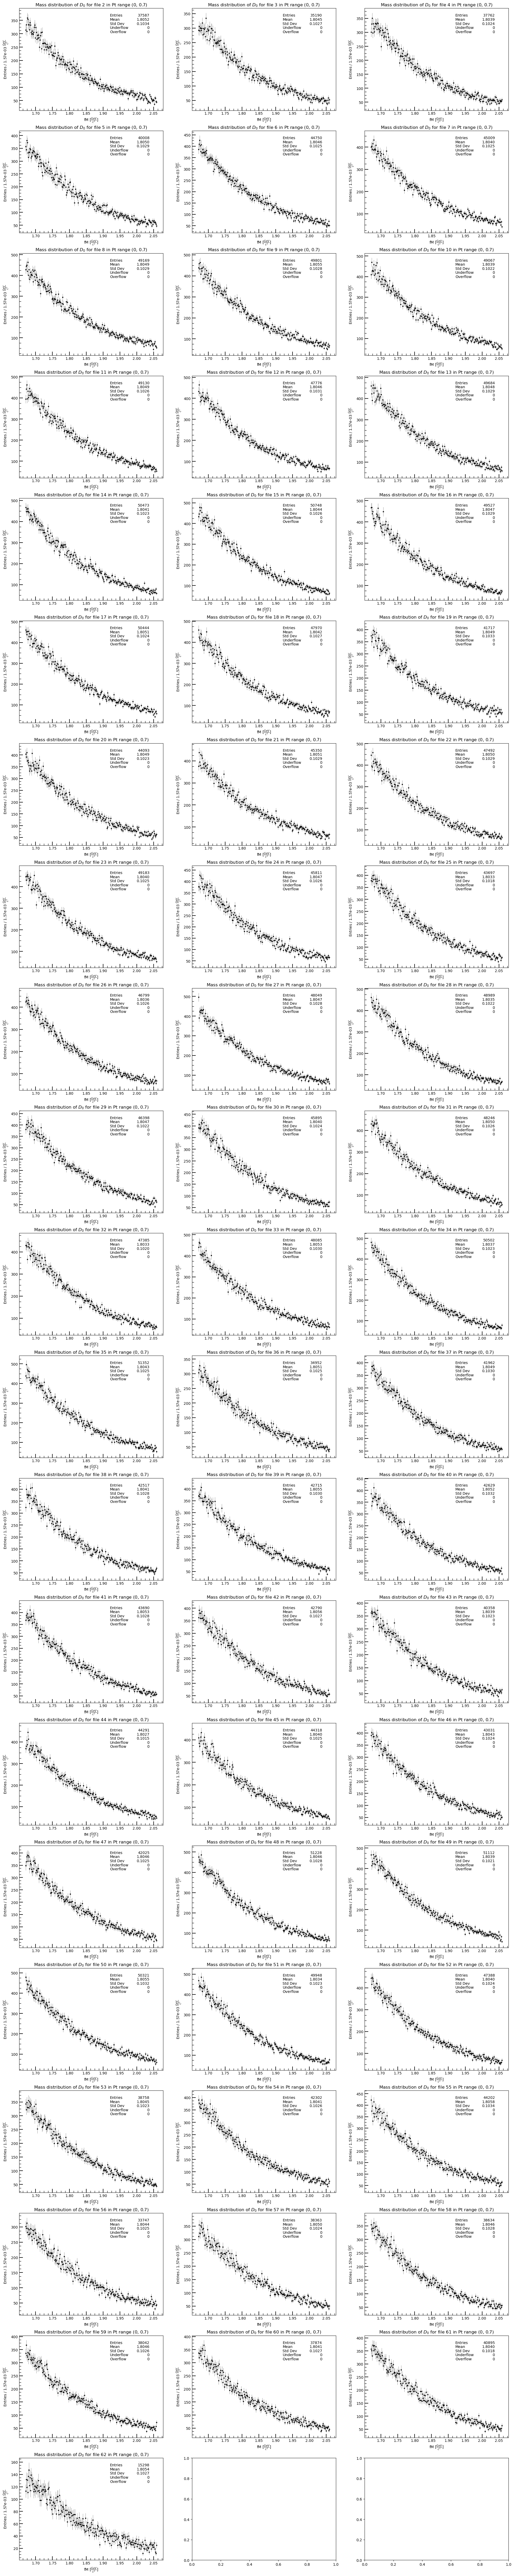

In [12]:
# the result can be saved on a file, and then loaded as trained model (as operative, but a new fit will produce a different model)
# the saved model store the necessary informations to classify but not to train again!
model_name = ( f"XGBoost_Fitted_Model_{particle}_Pt_Interval_{cut_index}.ubj" )
model = XGBClassifier()
model.load_model( model_name )

pars = pd.read_csv( f"/mnt/CandidateReducedDF/XGBoost_Cuts_{particle}_Pt_Interval_{cut_index}.csv" )
# pars = pd.read_csv( f"XGBoost_Cuts_{particle}_Pt_Interval_{cut_index}.csv" )
cut_dic = { 'Background' : pars['Background cut'][cut_subindex], 'Signal' : pars['Signal cut'][cut_subindex] , 'Beauty' : pars['Beauty cut'][cut_subindex] }

output_file = f"/mnt/CandidateReducedDF/Selected_{particle}_Pt_Int_{cut_index}_Sub_Pt_Int_{cut_subindex}.csv"


pt_int = sub_pt_range[ cut_index ][ cut_subindex ]

n_bin = 250
bins  = np.linspace( M_cut[cut_index][0], M_cut[cut_index][1], n_bin ) # bin edges
# histo = np.zeros( ( len( train_lab ), ( n_bin - 1 ) ) )

print( f"Pt interval used: {pt_int}")

figures = len( files )
cols = 3
rows = figures // cols + ( ( figures % cols ) > 0 )
# this always gives a 2d array for axs
fig, axs = plt.subplots( nrows = rows, ncols = cols, figsize=( 8*cols, 6*rows ), squeeze = False )


for i, file in enumerate( files ) :
    k = i+(3 if double_df else 2)
    # print( f"Analyzing chunk {k}" )
    # select the correct figure position
    n_col = i % cols
    n_row = i // cols
    ax = axs[ n_row ][ n_col ]
    Data_path = Part_path + file
    Data_df = get_cut_df( Data_path, col_sel, pt_int = pt_int, fY_cut = fY_cut, 
                    M_int = M_cut[cut_index], cuts = extra_cut, particle = particle )
    cut_data = xgcut_df( model, Data_df, train_col, train_lab, cut_dic )
    if i == 0 :
        cut_data.to_csv( output_file, columns = [ 'fM', 'fPt' ], mode = 'w', header = True, index = False )
    else :
        cut_data.to_csv( output_file, columns = [ 'fM', 'fPt' ], mode = 'a', header = False, index = False )
    # print( f"Saved chunk {k}")
    root_histo( cut_data, model, train_col, train_lab, cut_dic, key = 'fM', units = r'$\frac{GeV}{c^2}$',
                steps = 250, ax = ax, bins = bins, title = f"Mass distribution of {p_name} for file {k} in Pt range {pt_int}")
    del Data_df
    del cut_data

plt.show()

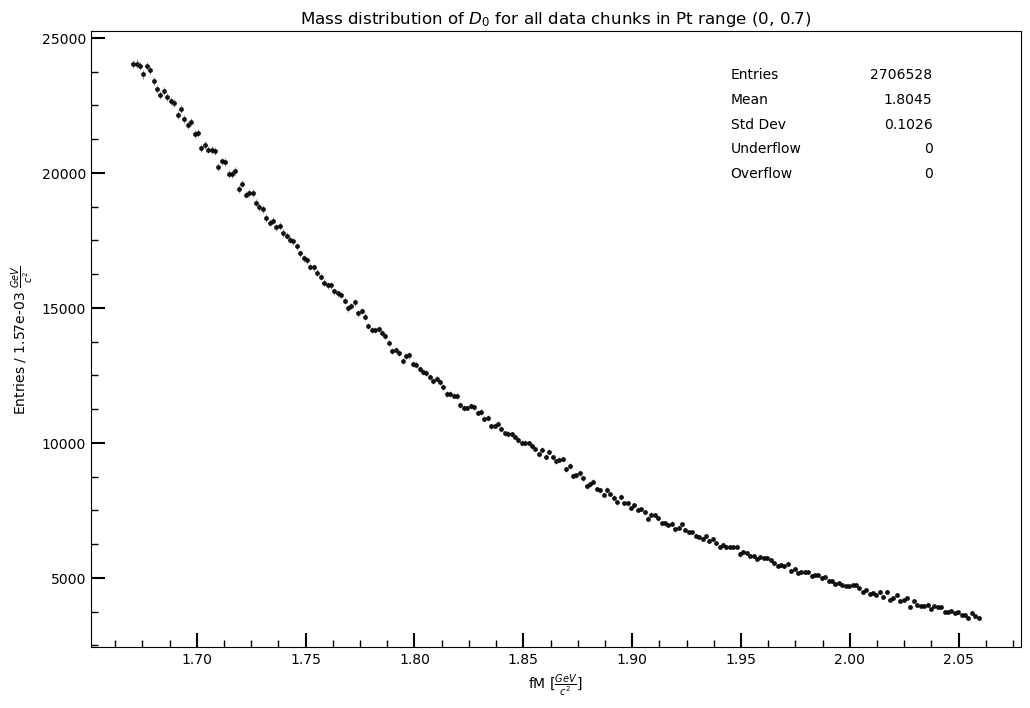

In [13]:
# all data plot
bins  = np.linspace( M_cut[cut_index][0], M_cut[cut_index][1], 250 ) # bin edges

data = pd.read_csv( output_file )
final_histo( data, key = 'fM', units = r'$\frac{GeV}{c^2}$',
            # steps = 250, bins = bins, title = f"Mass distribution for all data chunks in Pt range {pt_int}" )
            steps = 250, bins = bins, title = f"Mass distribution of {p_name} for all data chunks in Pt range {sub_pt_range[ cut_index ][ cut_subindex ]}" )
# del data